## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results Model 110**</span>

**Loss function configuration:**

$\lambda_{init} = 1$  
$\lambda_{phys} = 1$  
$\lambda_{bin} = 0$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

In [3]:
import utils.evaluation_tools as eval_tools


delta = 1 
shape = (15,15)
model_name = 'ClassicDiffGoL'
parent_folder = '../Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

threshold = 0.5
figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'ClassicDiffGoL Model'

th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta, model_name)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta, model_name)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta, model_name)
test_data = eval_tools.get_paths_results('test.npz', parent_folder, seeds, shape, delta, model_name)

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.2862 ± 0.0011
val_loss: 0.2920 ± 0.0016


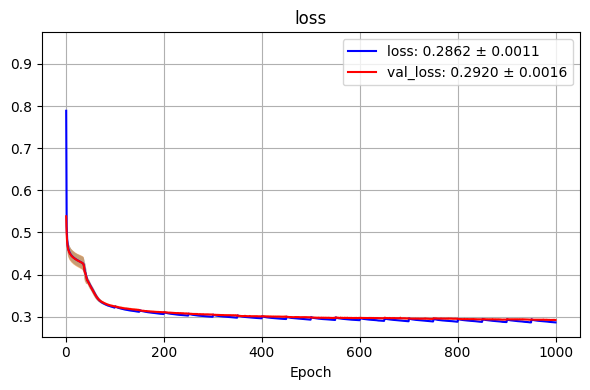

In [4]:
cols2omit = 1
num_rows = 1
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results**</u></span>

In [5]:
# Test:
eval_tools.display_results(test_results_paths, '_fin', display_plot=False)

--- Metrics computed during execution ---
Accuracy_init: 0.8500 ± 0.0005
Accuracy_fin: 0.8985 ± 0.0014
Recall_init: 0.5513 ± 0.0020
Recall_fin: 0.5436 ± 0.0061
Specificity_init: 0.9362 ± 0.0005
Specificity_fin: 0.9986 ± 0.0001
Precision_init: 0.7136 ± 0.0010
Precision_fin: 0.9909 ± 0.0004
F1Score_init: 0.6221 ± 0.0013
F1Score_fin: 0.7021 ± 0.0050


--- Results Initial States (15 seeds) ---
Density (true): 22.39% ± 9.39%
Density (pred): 28.46% ± 7.34%
Error/seed:     6.07% ± 0.17%
Max value predicted: 0.9999
HUC% (0.45, 0.55): 4.56% ± 0.07%
HUC% (0.4, 0.6): 9.52% ± 0.11%
HUC% (0.35, 0.65): 15.05% ± 0.15%
Fuzziness Index: 0.5572 ± 0.1108
MSE (prob):0.1187 ± 0.0592
MSE (bin):0.1500 ± 0.0908
MSE (all-zero): 0.2239 ± 0.0939
Wasserstein (EMD): 1.9121 ± 0.0326


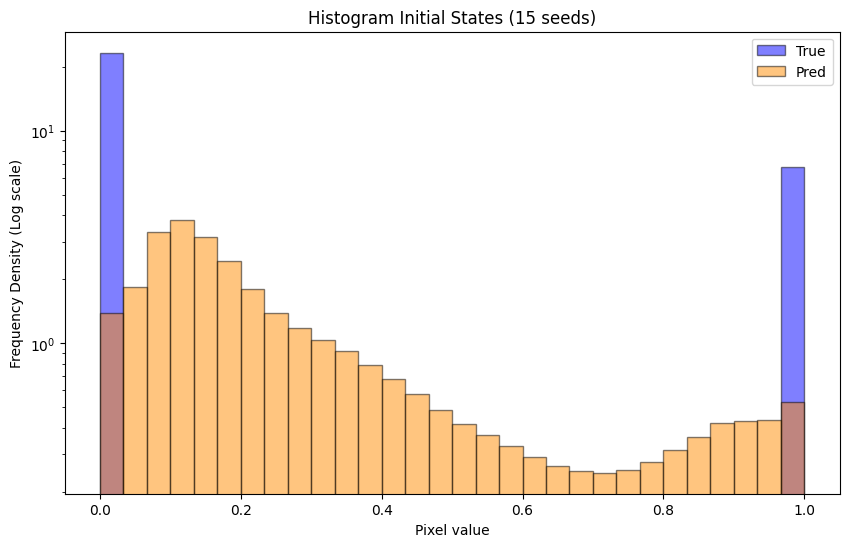

In [6]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'init', th_ranges, threshold, colors=['blue', 'darkorange'])

--- Results Final States (15 seeds) ---
Density (true): 22.00% ± 9.81%
Density (pred): 12.41% ± 4.38%
Error/seed:     9.59% ± 0.09%
Max value predicted: 0.9999
HUC% (0.45, 0.55): 3.32% ± 0.06%
HUC% (0.4, 0.6): 6.57% ± 0.09%
HUC% (0.35, 0.65): 9.68% ± 0.10%
Fuzziness Index: 0.1958 ± 0.0993
MSE (prob):0.0620 ± 0.0419
MSE (bin):0.1015 ± 0.0727
MSE (all-zero): 0.2200 ± 0.0981
Wasserstein (EMD): 1.2771 ± 0.0048


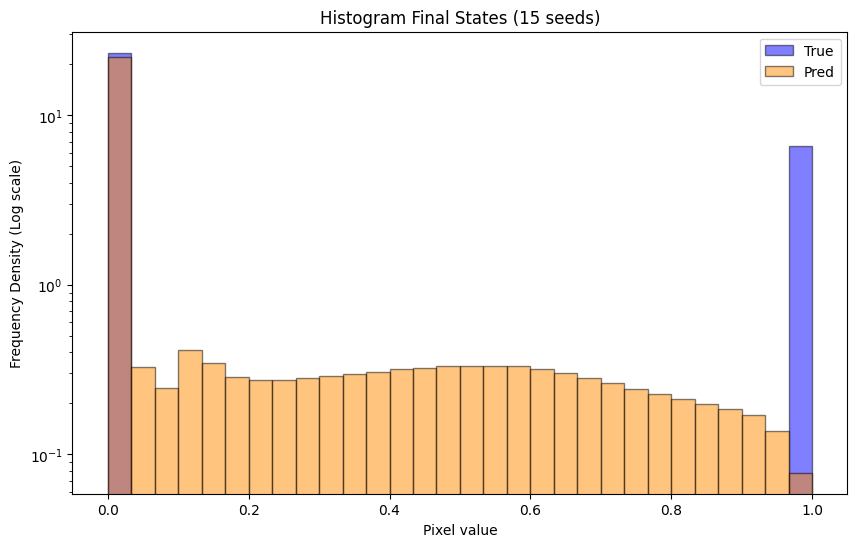

In [7]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'fin', th_ranges, threshold, colors=['blue', 'darkorange'])

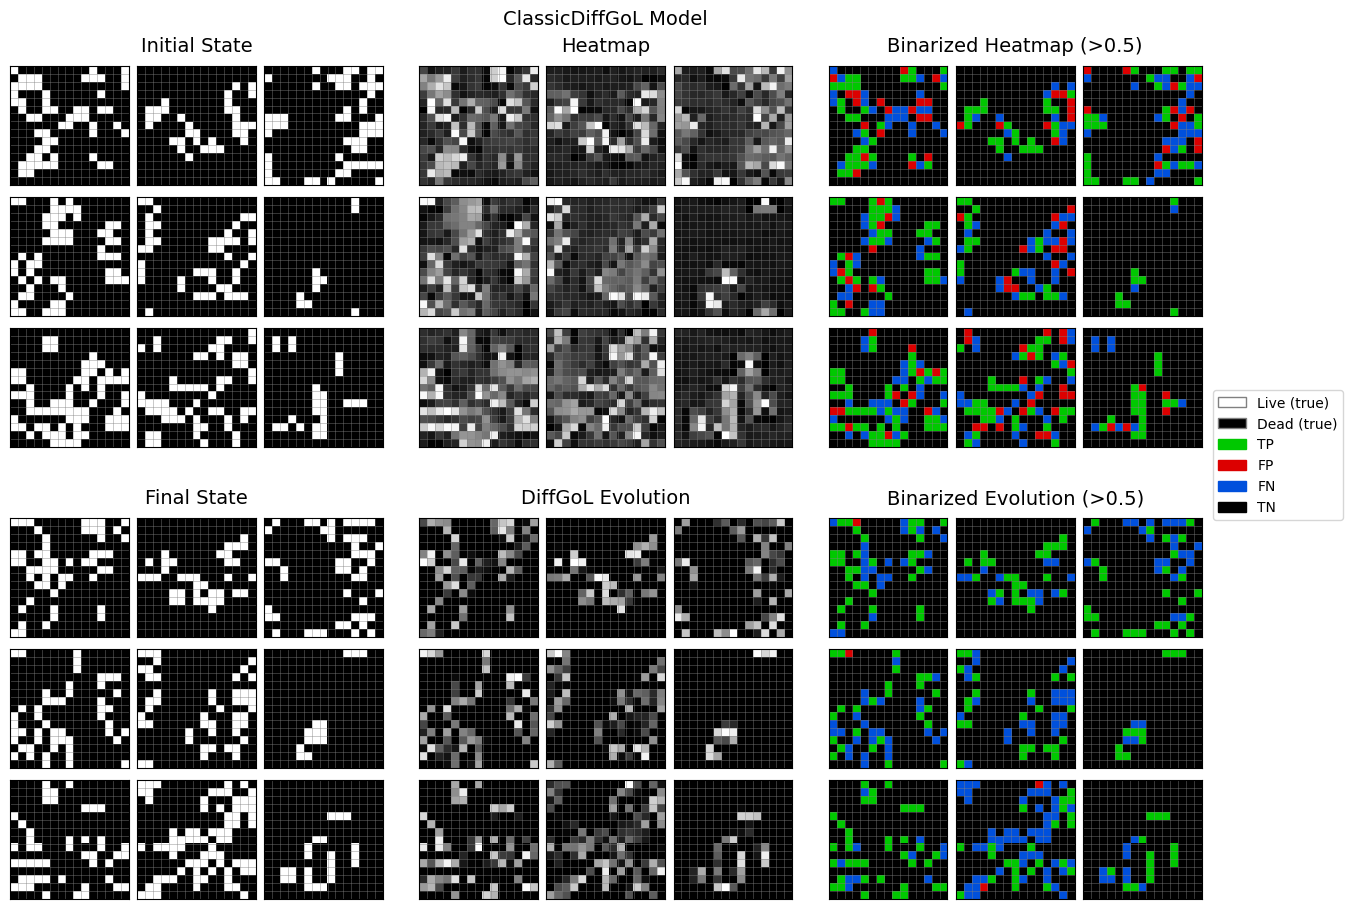

In [8]:
file_test = test_data[seed2plot]
file_pred = predictions_paths[seed2plot]
titles = ['Initial State', 'Heatmap', f'Binarized Heatmap (>{threshold})', 
          'Final State', 'DiffGoL Evolution', f'Binarized Evolution (>{threshold})']
eval_tools.display_states(file_pred, file_test, shape, threshold, titles, subplots_grid, suptitle, figsize, random=False)